# How to use torch-tk

This notebook is a practical introduction to torch-tk. It builds a minimal neural network model class and then trains, checkpoints, restores, and analyzes using torch-tk. The steps are:

- create a simple synthetic dataset for the example
- define a custom model class that is compatible with torch-tk and creates a model instance
- create an optimizer and specifies the loss function
- create a trainer and a checkpoint manager
- initialize diagnostics
- run a training loop and plots loss and wallclock time as functions of epoch
- save the model, optimizer, and diagnostics to disk
- recreate the model, optimizer, and diagnostics from disk
- create a new trainer and checkpoint manager
- resume training from the restored state, and plots loss and wallclock time as functions of epoch
- again save the model, optimizer, and diagnostics to disk
- finish by plotting the model diagnostics: PDFs of per-sample loss for the training and validation datasets as functions of epoch

## Preliminaries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import random
import numpy as np

import torch

from torch_tk.models import Model
from torch_tk.optimizers import Adam
from torch_tk.training import Trainer
from torch_tk.checkpoints import CheckPointManager
from torch_tk.diagnostics import Diagnostics, plot_positive_loss_kde_pdf

### Set random seed

In [3]:
seed = 999

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

### Set device

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

## Create a dataset

Input values are 1000 vectors of 100 random numbers

In [5]:
sample_n = 1000
in_dim_n = 100
out_dim_n = 1

In [6]:
x_data = torch.randn(size=[sample_n,in_dim_n],dtype=torch.float32)

Target values are the maximum of each of the 1000 vectors

In [7]:
y_data = x_data.amax(dim=tuple(range(1, x_data.ndim))).unsqueeze(1)

## Create a custom model class

We create a simple model class that can be used with the torch-tk `CheckPointManager`.

At its core, this class is like any torch model: it defines a `forward` method for the model forward pass.

A model used with torch-tk must provide the following method so that it can later be saved and reconstructed automatically:

- `constructor_dict` returns the arguments needed to recreate the model instance.

Rather than building all of this from scratch, we inherit from the abstract base class `torch_tk.models.Model`. This class inherits from `torch.nn.Module`. We only need to implement the model-specific parts.

In [8]:
class MyModel(Model):
    
    def __init__(self,in_dim_n,out_dim_n,device=None):
        
        super().__init__()
        
        self.in_dim_n = in_dim_n
        self.out_dim_n = out_dim_n
        self.device = device
        
        self.fc1 = torch.nn.Linear(in_dim_n,in_dim_n,device=device)
        self.ac1 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(in_dim_n,out_dim_n,device=device)

    def forward(self,xb):

        xb = self.fc1(xb)
        xb = self.ac1(xb)
        xb = self.fc2(xb)

        return xb

    def constructor_dict(self):
        '''
        Returns a dictionary with the model constructor arguments.
        '''
        return {
        'args' : (self.in_dim_n,self.out_dim_n),
        'kwargs' : {'device': self.device}
        }

## Create a model instance

In [9]:
model = MyModel(in_dim_n,out_dim_n,device=device)

In [10]:
model_name = type(model).__name__

## Create an optimizer

In [11]:
learning_rate = 1E-5

In [12]:
optimizer = Adam(model.parameters(),lr=learning_rate)

In [13]:
optimizer_name = type(optimizer).__name__

## Loss function

Sample-resolved loss function

In [14]:
def loss_function_sample_resolved(prediction, target):
    '''
    Compute the mean squared error for each prediction/target sample pair.
    '''
    error = prediction - target
    if error.ndim == 1:
        return error.pow(2).mean()
    return error.pow(2).mean(dim=tuple(range(1, error.ndim)))

Mean sample loss

In [15]:
def loss_function(prediction, target):
    '''
    Compute the mean of the sample-resolved loss.
    '''
    return loss_function_sample_resolved(prediction,target).mean()

## Create a trainer

In [16]:
trainer = Trainer(model,optimizer,loss_function)

## Create a checkpoint manager

In [17]:
checkpoint_dir = Path('checkpoints')

In [18]:
checkpoint_manager = CheckPointManager(model,optimizer,checkpoint_dir)

## Construct training and validation datasets

In [19]:
val_frac = 0.2
data_n = x_data.shape[0]
valid_n = int(0.2*data_n)
train_n = data_n - valid_n

Create a random permutation of the indices selecting model input

In [20]:
index_perm = torch.randperm(data_n)

Indices of the training and validation samples in the original dataset, if needed later

In [21]:
index_train = index_perm[0:train_n]
index_valid = index_perm[train_n:]

The training and validation datasets

In [22]:
train_data_description = 'Training data'
valid_data_description = 'Validation data'

In [23]:
x_train = x_data[index_train].to(device)
y_train = y_data[index_train].to(device)

x_valid = x_data[index_valid]
y_valid = y_data[index_valid]

## Training parameters

Batch size

In [24]:
batch_size = 20

Number of epoch cycles, number of epochs in each cycle, number of epochs before storing training diagnostics

In [25]:
epoch_cycles = 5
epochs = 100
training_diag_step = epochs

## Initialize diagnostics

In [26]:
diagnostics_dir = Path('diagnostics')

In [27]:
train_diagnostics = Diagnostics(model_name,optimizer_name,learning_rate,batch_size,description=train_data_description)
valid_diagnostics = Diagnostics(model_name,optimizer_name,learning_rate,batch_size,description=valid_data_description)

## Training loop

In [28]:
for cycle in range(epoch_cycles):
    # Training
    trainer.train_with_data(x_train,y_train,batch_size,epochs,epoch_diag_step=training_diag_step,x_valid=x_valid,y_valid=y_valid)
    # Calculate model diagnostics
    train_diagnostics += Diagnostics.from_data(model,loss_function_sample_resolved,optimizer,learning_rate,batch_size,x_train,y_train,description=train_data_description,epoch=trainer.epoch,chunk_size=2**16)
    valid_diagnostics += Diagnostics.from_data(model,loss_function_sample_resolved,optimizer,learning_rate,batch_size,x_valid,y_valid,description=valid_data_description,epoch=trainer.epoch,chunk_size=2**16)

Training epoch 100 wallclock time (s): 1.7558E-02, training loss : 1.591675, validation loss : 1.853556
Training epoch 200 wallclock time (s): 1.5357E-02, training loss : 0.256477, validation loss : 0.391800
Training epoch 300 wallclock time (s): 1.5618E-02, training loss : 0.131881, validation loss : 0.243211
Training epoch 400 wallclock time (s): 1.5508E-02, training loss : 0.090254, validation loss : 0.229738
Training epoch 500 wallclock time (s): 1.5450E-02, training loss : 0.061086, validation loss : 0.229412


### Save checkpoint

In [29]:
check_point_file = checkpoint_manager.save(trainer.epoch,batch_size)

### Save diagnostics

In [30]:
train_diag_file = train_diagnostics.to_netcdf(diagnostics_dir)
valid_diag_file = valid_diagnostics.to_netcdf(diagnostics_dir)

Saved diagnostics in  diagnostics/MyModel.Adam.Training data.epoch=100_to_500.nc
Saved diagnostics in  diagnostics/MyModel.Adam.Validation data.epoch=100_to_500.nc


### Plot training diagnostics

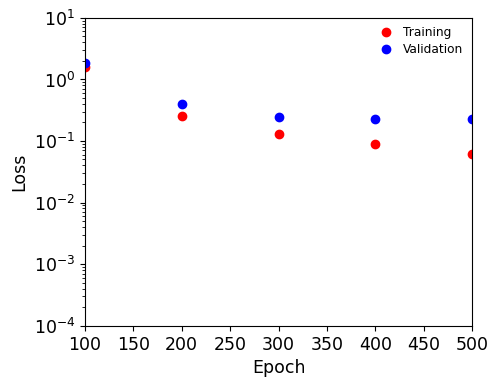

In [31]:
trainer.plot_loss(figsize=(5, 4),font_factor=1.25,ylog=True,ylim=[0.0001,10])

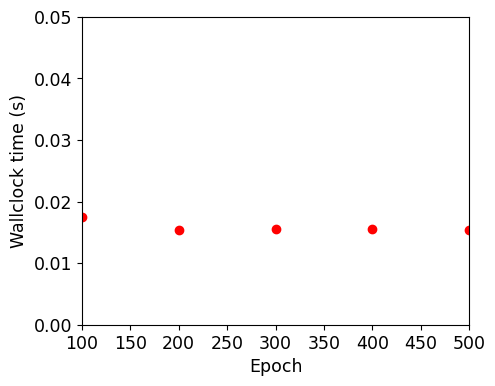

In [32]:
trainer.plot_wallclock_time(figsize=(5, 4),font_factor=1.25,ylim=[0,5e-2])

### Discard the existing model, optimizer, checkpoint manager, and diagnostics instances (we will recreate them from saved files)

In [33]:
model = None
optimizer = None
checkpoint_manager = None
train_diagnostics = None
valid_diagnostics = None

## Recreate the model, optimizer, and diagnostics from saved files

Load the saved checkpoint file and reconstruct the checkpoint manager, model, and optimizer

In [34]:
checkpoint_manager, model, optimizer, epoch, batch_size = CheckPointManager.load_from_file(check_point_file)

Load the saved diagnostics file

In [35]:
train_diagnostics = Diagnostics.from_netcdf(train_diag_file)
valid_diagnostics = Diagnostics.from_netcdf(valid_diag_file)

## Create a trainer

Initialize the trainer with the last epoch from the previous training

In [36]:
trainer = Trainer(model,optimizer,loss_function,epoch=epoch)

## Training loop

In [37]:
for cycle in range(epoch_cycles):
    # Training
    trainer.train_with_data(x_train,y_train,batch_size,epochs,epoch_diag_step=training_diag_step,x_valid=x_valid,y_valid=y_valid)
    # Calculate model diagnostics
    train_diagnostics += Diagnostics.from_data(model,loss_function_sample_resolved,optimizer,learning_rate,batch_size,x_train,y_train,description=train_data_description,epoch=trainer.epoch,chunk_size=2**16)
    valid_diagnostics += Diagnostics.from_data(model,loss_function_sample_resolved,optimizer,learning_rate,batch_size,x_valid,y_valid,description=valid_data_description,epoch=trainer.epoch,chunk_size=2**16)

Training epoch 600 wallclock time (s): 1.6247E-02, training loss : 0.038200, validation loss : 0.232427
Training epoch 700 wallclock time (s): 1.6297E-02, training loss : 0.021078, validation loss : 0.236565
Training epoch 800 wallclock time (s): 1.6002E-02, training loss : 0.009593, validation loss : 0.240942
Training epoch 900 wallclock time (s): 1.5886E-02, training loss : 0.003106, validation loss : 0.245218
Training epoch 1000 wallclock time (s): 1.5866E-02, training loss : 0.000453, validation loss : 0.248719


### Save checkpoint

In [38]:
check_point_file = checkpoint_manager.save(trainer.epoch,batch_size)

### Save diagnostics

In [39]:
train_diag_file = train_diagnostics.to_netcdf(diagnostics_dir)
valid_diag_file = valid_diagnostics.to_netcdf(diagnostics_dir)

Saved diagnostics in  diagnostics/MyModel.Adam.Training data.epoch=100_to_1000.nc
Saved diagnostics in  diagnostics/MyModel.Adam.Validation data.epoch=100_to_1000.nc


### Plot training diagnostics

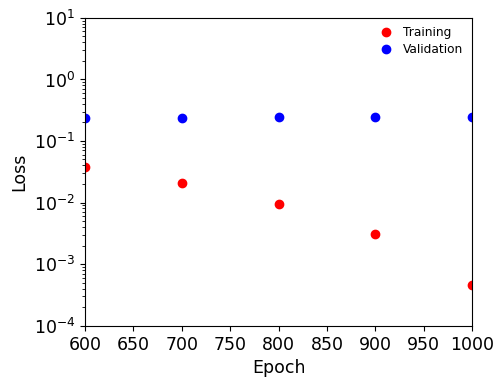

In [40]:
trainer.plot_loss(figsize=(5, 4),font_factor=1.25,ylog=True,ylim=[0.0001,10])

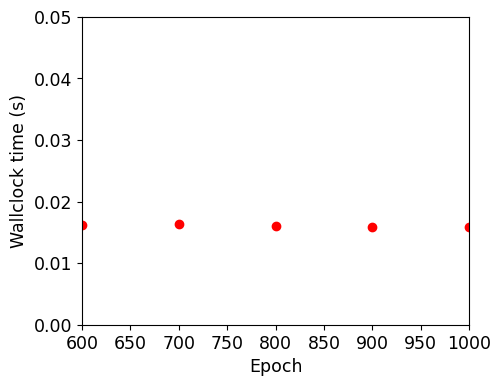

In [41]:
trainer.plot_wallclock_time(figsize=(5, 4),font_factor=1.25,ylim=[0,5e-2])

## Plot model diagnostics

The plots show the loss probability distribution function (PDF) at different epochs, and compare the training and the validation datasets. The plots show that:
- The PDFs exhibit one dominant mode, which suggests there is not obvious evidence of persistent multiple distinct sample subpopulations with very different error regimes.
- With increasing epoch number, the training distribution shifts toward lower loss values, while the validation distribution changes little. That is consistent with overfitting: the model continues improving on the training dataset but not on the validation dataset, indicating it generalizes poorly.

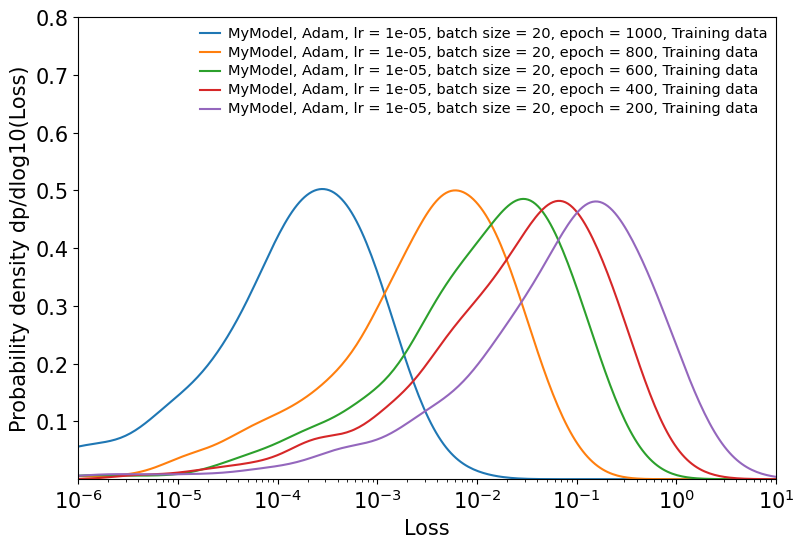

In [42]:
plot_positive_loss_kde_pdf(train_diagnostics,per_dlog10=True,xlim=[1e-6,1e1],ylim=[1E-4,0.8],epoch_skip=2,bin_n=500)

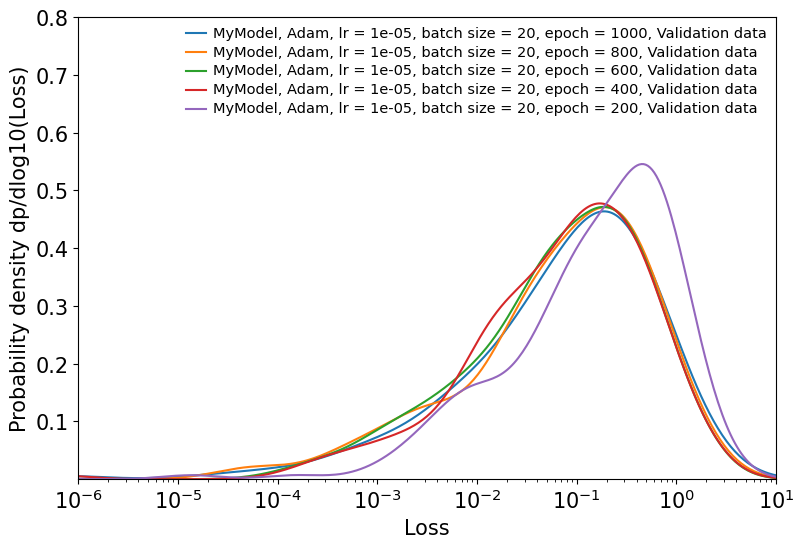

In [43]:
plot_positive_loss_kde_pdf(valid_diagnostics,per_dlog10=True,xlim=[1e-6,1e1],ylim=[1E-4,0.8],epoch_skip=2,bin_n=500)